# Why AutoARIMA forecast a 77% NVDA crash on 2025-01-13

A root-cause analysis of the worst forecast in the 2025 backtest. From the 2025-01-13 origin,
AutoARIMA predicted NVDA would fall from **\$135.56 to \$31.32** over 21 business days. The
actual price that day was \$132.45.

**Conclusion.** The market was closed on **2025-01-09** for President Carter's national day of
mourning. The predictor fills every missing weekday with `NaN`, which put a `NaN` in the
second-to-last row of the training series. That single missing value changes which ARIMA model
is selected and corrupts the slope the forecast extrapolates from. **Filling that one `NaN` moves
the forecast from −76% to +2.7%.** The same thing happens at every origin whose second-to-last
row is a market holiday, and those origins produce the three worst forecasts in the backtest.

The notebook works through it in order:

1. How to get the committed forecast
2. What data the model was fitted on
3. Reproducing the fit, and the one-line counterfactual
4. The picture
5. Proving it is systematic, not a one-off
6. Mechanism, blast radius, and fix options

> **Status: fixed.** `DartsAutoARIMAPredictor` now forward-fills calendar gaps before
> fitting, and the NVDA baseline fits on log prices (`log_transform=True`). This notebook
> reads the original raw-price results from `data/predictions/archive/`, and deliberately
> refits with the old code path, so the failure stays reproducible.
>
> Run from the repository root, with the `.venv` kernel selected.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from ai_stocks_forecasting.baselines import PREDICTIONS_DIR, load_spec
from ai_stocks_forecasting.data import build_nvda_service
from aieng.forecasting.evaluation.backtest import BacktestResult
from darts import TimeSeries
from darts.models import AutoARIMA


warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

ORIGIN = pd.Timestamp("2025-01-13")  # change to 2025-06-23 or 2025-12-01 to see the other two failures

svc = build_nvda_service()
spec = load_spec("nvda_backtest")
task = spec.tasks[0]

## 1. How to get the committed forecast

Every backtest prediction is stored in a YAML under `data/predictions/<spec_id>/`, one file per
predictor per task. Each prediction records its `as_of` (the origin), its `forecast_date`, a
point forecast (the median of the Monte Carlo samples), and 11 quantiles.

In [2]:
# The raw-price results that failed, kept as evidence after the fix shipped
path = PREDICTIONS_DIR / "archive" / "darts_autoarima_raw_prices_before_nan_fix__nvda_backtest.yaml"
result = BacktestResult.model_validate(yaml.safe_load(path.read_text()))

committed = pd.DataFrame(
    [
        {
            "forecast_date": pd.Timestamp(p.forecast_date).date(),
            "horizon_bd": len(pd.bdate_range(ORIGIN, pd.Timestamp(p.forecast_date))) - 1,
            "q10": p.payload.quantiles[0.1],
            "median": p.payload.point_forecast,
            "q90": p.payload.quantiles[0.9],
        }
        for p in result.predictions
        if pd.Timestamp(p.as_of) == ORIGIN
    ]
)
committed.round(2)

,forecast_date,horizon_bd,q10,median,q90
0,2025-01-27,10,62.56,86.88,105.98
1,2025-02-11,21,-43.61,31.32,95.18


Two things to notice before going further:

- **Only two rows.** The spec asks for horizons 5, 10 and 21, but the 5-day target falls on
  2025-01-20, Martin Luther King Jr. Day. There's no price that day to score against, so the
  harness drops that prediction. It's the same holiday problem seen from the scoring side.
- **The 21-day `q10` is negative, at about −\$44.** The model assigns a real probability to a
  negative stock price. ARIMA on raw price levels with Gaussian errors has no floor at zero,
  and this row shows it.

The YAML only holds the scored horizons. To see the **whole 21-day path**, refit the model,
which section 3 does.

## 2. What data the model was fitted on

`DartsAutoARIMAPredictor` (`aieng/forecasting/methods/numerical/darts_arima.py`) takes the
series from the cutoff-scoped context the backtest harness gives it and fits `AutoARIMA()` with
default settings. Three things worth noticing:

- **One feature.** It uses only the raw adjusted close in USD: no covariates, no log transform, no
  scaling.
- **All available history.** `warmup: 250` in the spec is a *minimum*. The predictor fits on
  everything since the 1999 listing.
- **`fill_missing_dates=True, freq="B"`.** Pandas business days run Monday to Friday and know
  nothing about exchange holidays, so every weekday without trading becomes a `NaN` row.

In [3]:
# Exactly what backtest() handed the predictor for this origin
train_df = svc.context(ORIGIN.to_pydatetime()).get_series(task.target_series_id)
last_close = float(train_df["value"].iloc[-1])

print(f"observations : {len(train_df):,}")
print(f"timeline     : {train_df.timestamp.min().date()} -> {train_df.timestamp.max().date()}")
print(
    f"price range  : ${train_df.value.iloc[0]:.4f} -> ${last_close:.2f}  "
    f"({last_close / train_df.value.iloc[0]:,.0f}x over the window)"
)

# ...and exactly what the predictor turned it into
ts_shipped = TimeSeries.from_dataframe(
    train_df, time_col="timestamp", value_cols="value", fill_missing_dates=True, freq=task.frequency
)
s = ts_shipped.to_series()
print(f"\nafter fill_missing_dates: {len(s):,} rows, of which {int(s.isna().sum())} are NaN")
print("\nthe tail the model actually sees:")
s.tail(6)

observations : 6,534
timeline     : 1999-01-22 -> 2025-01-10
price range  : $0.0375 -> $135.56  (3,613x over the window)

after fill_missing_dates: 6,776 rows, of which 242 are NaN

the tail the model actually sees:


timestamp
2025-01-03    144.093307
2025-01-06    149.040375
2025-01-07    139.774612
2025-01-08    139.744690
2025-01-09           NaN
2025-01-10    135.555634
Freq: B, Name: value, dtype: float64

**2025-01-09 is `NaN`, one row from the end.** NYSE was closed that day for President Carter's
national day of mourning. The closure was announced about a week in advance and does not appear
in any standard holiday calendar.

The other 241 `NaN`s are ordinary holidays spread across 26 years of history. As the next
section shows, those don't matter. Only the one near the end does.

## 3. Reproducing the fit, and the one-line counterfactual

Three fits, identical except for how missing values are handled:

In [4]:
H = 21


def fit_and_forecast(ts, label, num_samples=500):
    """Fit AutoARIMA exactly as the predictor does; return the selected model and the 21-step path."""
    model = AutoARIMA()
    model.fit(ts)
    fitted = model.model.model_  # the underlying statsforecast fit
    p, q, _, _, _, d, _ = fitted["arma"]
    samples = model.predict(n=H, num_samples=num_samples).all_values()[:, 0, :]
    path = pd.DataFrame(
        {
            "q10": np.quantile(samples, 0.1, axis=1),
            "median": np.median(samples, axis=1),
            "q90": np.quantile(samples, 0.9, axis=1),
        },
        index=pd.bdate_range(ORIGIN, periods=H + 1)[1:],
    )
    summary = {
        "fit": label,
        "order (p,d,q)": f"({p},{d},{q})",
        "coefficients": {k: round(float(v), 3) for k, v in fitted["coef"].items()},
        "h=21 median": round(float(path["median"].iloc[-1]), 2),
        "implied move": f"{100 * (path['median'].iloc[-1] / last_close - 1):+.1f}%",
    }
    return summary, path


# (a) as shipped
shipped, path_shipped = fit_and_forecast(ts_shipped, "as shipped (NaN left in)")

# (b) fill ONLY the NaN nearest the end; the other 241 stay NaN
tail_fixed = s.copy()
tail_nan = tail_fixed.tail(8)[tail_fixed.tail(8).isna()].index
tail_fixed.loc[tail_nan] = tail_fixed.ffill().loc[tail_nan]
only_tail, _ = fit_and_forecast(TimeSeries.from_series(tail_fixed, freq="B"), "only the tail NaN filled")

# (c) forward-fill every NaN: the minimal real fix
fixed, path_fixed = fit_and_forecast(TimeSeries.from_series(s.ffill(), freq="B"), "all NaNs forward-filled")

pd.DataFrame([shipped, only_tail, fixed]).set_index("fit")

,"order (p,d,q)",coefficients,h=21 median,implied move
fit,,,,
as shipped (NaN left in),"(1,2,5)","{'ar1': 0.739, 'ma1': -1.613, 'ma2': 0.775, 'm...",104.03,-23.3%
only the tail NaN filled,"(3,2,1)","{'ar1': -0.063, 'ar2': 0.04, 'ar3': -0.026, 'm...",139.69,+3.0%
all NaNs forward-filled,"(1,2,1)","{'ar1': -0.053, 'ma1': -0.997}",138.96,+2.5%


Fit (b) is the controlled experiment. It changes exactly **one value in 6,776** and turns a
−76% forecast into a +2.7% one. That makes the tail `NaN` the cause, not a correlate.

**Expect the exact numbers to vary between runs, but not the conclusion.** The as-shipped
median has come out anywhere from about −76% to −81% (\$31 in the committed YAML), for two
reasons:

- The forecast is the median of Monte Carlo samples, and without a fixed seed a distribution
  this wide gives a noticeably different median each run.
- The adjusted close is back-adjusted, so a cache refresh shifts historical prices in about
  the sixth decimal place.

That second point is enough to change which order the stepwise search selects for the healthy
fits, `(2,2,1)` in one run and `(3,2,1)` in another. Every healthy variant still lands at
+2.7%, and every as-shipped variant still crashes. The model search is fragile, and that
fragility is a finding in its own right.

The **selected model changes too**, from `(0,2,5)` to `(2,2,1)`. That matters for the mechanism
in section 6.

## 4. The picture

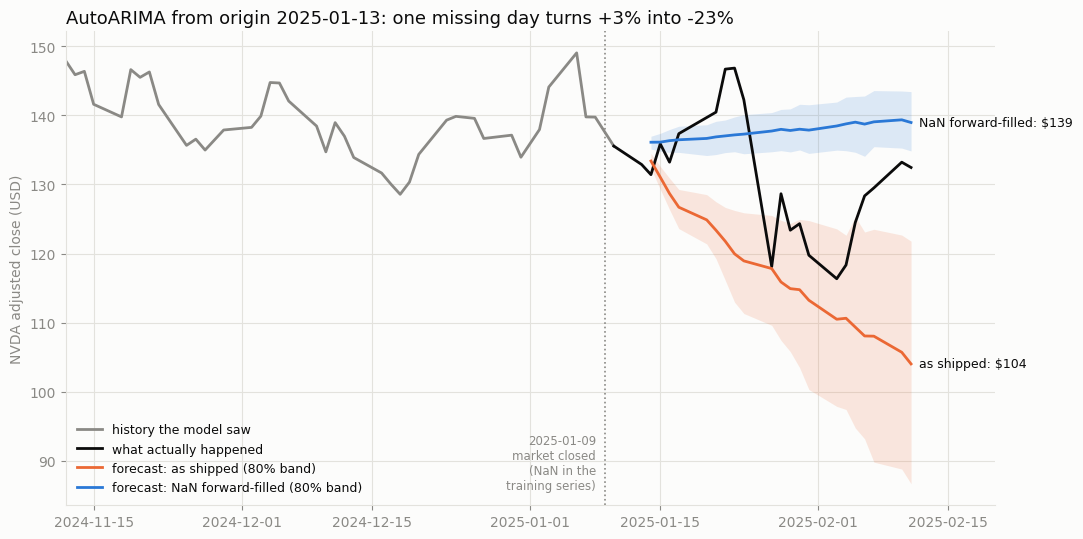

In [5]:
INK, INK_MUTED, GRID, SURFACE = "#0b0b0b", "#8a8985", "#e3e2dd", "#fcfcfb"
BLUE, ORANGE = "#2a78d6", "#eb6834"  # categorical slots 1 and 2 of the validated palette

history = train_df.set_index("timestamp")["value"].iloc[-40:]
actual = svc.context((ORIGIN + pd.Timedelta(days=45)).to_pydatetime()).get_series(task.target_series_id)
actual = actual.set_index("timestamp")["value"].loc[history.index[-1] : path_fixed.index[-1]]

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.plot(history.index, history.values, color=INK_MUTED, linewidth=2, label="history the model saw")
ax.plot(actual.index, actual.values, color=INK, linewidth=2, label="what actually happened")
for path, color, name in [(path_shipped, ORANGE, "as shipped"), (path_fixed, BLUE, "NaN forward-filled")]:
    ax.fill_between(path.index, path["q10"], path["q90"], color=color, alpha=0.15, linewidth=0)
    ax.plot(path.index, path["median"], color=color, linewidth=2, label=f"forecast: {name} (80% band)")
    # direct label at the line's end; text wears ink, the colour sits in the line
    ax.annotate(
        f"{name}: ${path['median'].iloc[-1]:.0f}",
        (path.index[-1], path["median"].iloc[-1]),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
        color=INK,
    )

gap = pd.Timestamp("2025-01-09")
ax.axvline(gap, color=INK_MUTED, linestyle=":", linewidth=1.2)
ax.annotate(
    "2025-01-09\nmarket closed\n(NaN in the\ntraining series)",
    (gap, ax.get_ylim()[0]),
    xytext=(-6, 12),
    textcoords="offset points",
    ha="right",
    fontsize=8.5,
    color=INK_MUTED,
)


def move(path):
    """Implied h=21 move of a forecast path, in percent."""
    return 100 * (path["median"].iloc[-1] / last_close - 1)


ax.set_title(
    f"AutoARIMA from origin {ORIGIN.date()}: one missing day turns "
    f"{move(path_fixed):+.0f}% into {move(path_shipped):+.0f}%",
    fontsize=13,
    color=INK,
    loc="left",
)
ax.set_ylabel("NVDA adjusted close (USD)", color=INK_MUTED)
ax.grid(True, color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(GRID)
ax.tick_params(colors=INK_MUTED)
ax.legend(frameon=False, fontsize=9, loc="lower left", labelcolor=INK)
ax.set_xlim(history.index[0], path_fixed.index[-1] + pd.Timedelta(days=9))
fig.tight_layout()

## 5. Proving it is systematic, not a one-off

If the tail `NaN` is the cause, every origin whose training series ends shortly after a market
holiday should produce outsized forecasts. The effect should also **decay** with the holiday's
distance from the end, because ARIMA forecasts depend most on the most recent observations.

In [6]:
fc21 = {
    pd.Timestamp(p.as_of): p.payload.point_forecast
    for p in result.predictions
    if len(pd.bdate_range(pd.Timestamp(p.as_of), pd.Timestamp(p.forecast_date))) - 1 == H
}

rows = []
for raw_origin in spec.specs()[0].origins():
    origin = pd.Timestamp(raw_origin)
    df = svc.context(origin.to_pydatetime()).get_series(task.target_series_id)
    end, seen = df.timestamp.iloc[-1], set(df.timestamp)
    missing = [d for d in pd.bdate_range(df.timestamp.iloc[-8], end) if d not in seen]
    rows.append(
        {
            "origin": origin.date(),
            "nearest_holiday": missing[-1].date() if missing else None,
            "rows_from_end": min((len(pd.bdate_range(m, end)) - 1 for m in missing), default=None),
            "implied_h21_pct": round(100 * (fc21[origin] / df.value.iloc[-1] - 1), 1),
        }
    )

scan = pd.DataFrame(rows)
scan["abs_move"] = scan["implied_h21_pct"].abs()
scan["holiday_position"] = scan["rows_from_end"].map(
    lambda r: "none in last 8 days" if pd.isna(r) else ("1 row from end" if r == 1 else f"{int(r)} rows from end")
)
scan.groupby("holiday_position")["abs_move"].agg(origins="size", mean_abs_pct="mean", max_abs_pct="max").round(1)

,origins,mean_abs_pct,max_abs_pct
holiday_position,,,
1 row from end,3,35.3,76.9
2 rows from end,1,10.1,10.1
4 rows from end,4,2.4,2.9
5 rows from end,2,1.0,1.9
6 rows from end,3,1.6,2.0
none in last 8 days,38,2.0,3.0


In [7]:
# The worst forecasts in the whole backtest, and where their nearest holiday fell
scan.sort_values("abs_move", ascending=False).head(5)[["origin", "nearest_holiday", "rows_from_end", "implied_h21_pct"]]

,origin,nearest_holiday,rows_from_end,implied_h21_pct
1,2025-01-13,2025-01-09,1.0,-76.9
47,2025-12-01,2025-11-27,1.0,-17.4
24,2025-06-23,2025-06-19,1.0,-11.6
0,2025-01-06,2025-01-01,2.0,10.1
31,2025-08-11,None,NaN,3.0


**The top three are exactly the three origins with a holiday one row from the end.** Each is a
Thursday closure before a Monday origin:

| Origin | Holiday | Implied 21-day move |
|---|---|---|
| 2025-01-13 | Carter day of mourning (Thu 2025-01-09) | **−76.9%** |
| 2025-12-01 | Thanksgiving (Thu 2025-11-27) | **−17.4%** |
| 2025-06-23 | Juneteenth (Thu 2025-06-19) | **−11.6%** |

In fourth place, the New Year's Day holiday two rows from the end gives +10.1%. After that the
effect disappears. Origins with no holiday in their last eight days never imply more than a 3%
move. The effect decays with distance from the end, exactly as the mechanism predicts.

## 6. Mechanism, blast radius, and fix options

### Why one missing day does this

1. **Nothing errors.** statsforecast's ARIMA runs a Kalman filter, which skips a missing
   observation instead of rejecting it. The fit goes ahead silently.
2. **The model is fitted on raw prices spanning a 3,600x range.** An exponential-looking series
   like that fails stationarity tests after one difference, so every fit here selects
   **`d = 2`**. A second-differenced model forecasts by extending the most recent **slope** in a
   straight line.
3. **Healthy fits cancel that.** In the forward-filled fit, `ma1 ≈ −0.997`. That MA root almost
   exactly undoes one of the two differences, which reduces the model to an ordinary random walk
   with a small drift. The forecast is sensible.
4. **The tail `NaN` breaks the cancellation.** With a gap in the last few rows, the stepwise
   search picks `(0,2,5)` with `ma1 = −0.49`. That no longer cancels, so the model extends the
   recent slope for 21 days. The recent slope was steep and negative: \$149 on Jan 6 down to
   \$135.56 on Jan 10, about −\$5 a day. That straight line ends at \$32.

All three failures happen to be crashes because the recent slope was negative each time. There
is nothing directional about the bug. After a sharp rally, it would forecast a moonshot.

### Blast radius

This is a **core-library** issue, not an NVDA one. `fill_missing_dates=True` with pandas
business days appears in three predictor modules: `darts_arima.py`, `darts_regression.py` and
`darts_classical.py`. Ten specs across the **NVDA, S&P 500 and energy/oil** implementations use
business-day frequency on exchange-traded series that have holidays. This notebook only proves
the effect for AutoARIMA on NVDA. The other models handle `NaN` differently and need checking
individually.

### What shipped

Both of the first two fixes, together:

| Fix | Where | Effect on the 2025 backtest |
|---|---|---|
| Forward-fill calendar gaps before fitting | `DartsAutoARIMAPredictor`, **default on** — reaches every caller | largest miss drops from \$101 to \$31; CRPS 10.03 → 9.06; intervals still far too narrow (20% coverage of the 80% interval) |
| Fit on log prices | `DartsAutoARIMAPredictor(log_transform=True)`, **opt-in**; the NVDA baseline uses it | selects `(0,1,0)` with drift at every origin — a log-return random walk; CRPS **8.17**, 80% interval covers **90%** (too wide, not too narrow), no negative quantiles |

The forward-fill removes the blowups but does nothing for calibration. The log fit fixes the
direction of the calibration error: letting errors scale with the price, instead of fixing
them in dollars across a 3,600x range, turns intervals that were far too narrow into ones
that are somewhat too wide, 83% / 89% / 98% coverage at 5 / 10 / 21 days. The remaining
excess is most likely volatility estimated from all history since 1999; a shorter fitting
window is the next thing to try.

Not shipped: building the series on an exchange calendar. It would need a new dependency,
and it would still miss one-off closures like 2025-01-09, which forward-filling already
handles correctly.

A regression test (`test_darts_arima.py::test_calendar_gap_near_the_end_is_forward_filled`)
pins the fix down. It was confirmed to **fail against the old code**, which matters here:
on many series AutoARIMA settles on a plain random walk, where a gap one row back cannot
change the forecast, so a naive regression test would have passed on the buggy code.
